#### imports
- Some images are cropped and are non-square
- Need to fix this before training

In [ ]:
import tensorflow as tf
import keras
from keras.saving import load_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.applications import MobileNetV2
from keras import layers,models
from tensorflow import data as tf_data
import os
import random
import zipfile
import shutil
import pandas as pd
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay,classification_report)
import reload_data2
from google.colab import drive
drive.mount('/content/drive')
import random
from IPython.display import Image, display

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from PIL import Image
import cv2
from tqdm import tqdm

## Data Loading

In [ ]:
df = pd.read_csv("/content/Handwriting_Metadata_clean.csv")
df=df.sort_values(by="wid").reset_index(drop=True)
df.head(5)

,wid,agegroup,gender,handedness
0,w0001,25-40,female,right
1,w0002,41-60,male,right
2,w0003,25-40,female,right
3,w0004,18-24,female,ambidextrous
4,w0005,18-24,male,right


In [ ]:
drive_dir="/content/drive/MyDrive/CSAFE_zips"
data_dir = "/content/Data"

In [ ]:
%%time
try:
    shutil.rmtree(data_dir)
    os.mkdir(data_dir)
except:
    pass

zips=list()
for path in os.listdir("/content/drive/MyDrive/CSAFE_zips"):
    if ".zip" in path:
        zips.append(path)

for z in zips:
    print(f"Unzipping: {z}")
    try:
        reload_data2.unzip(f"{drive_dir}/{z}",data_dir)
    except zipfile.BadZipFile:
        print(f"ERROR: {z}")
    print()

Unzipping: CSAFE_All_Images_3.zip

Unzipping: CSAFE_All_Images_4.zip

Unzipping: CSAFE_All_Images_1.zip

Unzipping: CSAFE_All_Images_2.zip

CPU times: user 16.6 s, sys: 5.04 s, total: 21.6 s
Wall time: 1min


In [ ]:
list(os.listdir(data_dir))[::800]

['w0399_s02_pLND_r02.png',
 'w0191_s02_pWOZ_r02.png',
 'w0352_s02_pWOZ_r02.png',
 'w0435_s03_pWOZ_r02.png',
 'w0675_s03_pWOZ_r03.png',
 'w0263_s03_pLND_r01.png',
 'w0564_s01_pWOZ_r02.png',
 'w0637_s02_pLND_r03.png',
 'w0402_s02_pWOZ_r01.png',
 'w0350_s02_pLND_r03.png',
 'w0594_s02_pLND_r02.png',
 'w0134_s02_pPHR_r01.png',
 'w0529_s03_pLND_r03.png',
 'w0577_s03_pLND_r03.png',
 'w0533_s01_pLND_r01.png',
 'w0121_s03_pWOZ_r01.png',
 'w0444_s01_pLND_r03.png']

In [ ]:
reload_data2.organize_unzipped_files(data_dir)

In [ ]:
reload_data2.stratify_split_alt(data_dir,475)

Using 475 class labels


In [ ]:
IMAGE_SIZE = (384,384)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 475

In [ ]:

def opencv_make_square(img_path):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # Calculate how much padding is needed
    diff = abs(w - h)

    if w > h:
        # Pad the bottom
        return cv2.copyMakeBorder(img, 0, diff, 0, 0,
                                  cv2.BORDER_CONSTANT,
                                  value=[255, 255, 255])
    else:
        # Pad the right side
        return cv2.copyMakeBorder(img, 0, 0, 0, diff,
                                  cv2.BORDER_CONSTANT,
                                  value=[255, 255, 255])

# Usage
# square_img = make_square_padding("your_image.jpg")
# square_img.save("squared.jpg")

In [ ]:
new_data_dir="New_Data"
os.mkdir(new_data_dir)

In [10]:
%%time
import os
import PIL
from PIL import Image
from tqdm import tqdm
def process_dataset(input_root, output_root, target_size=None):
    """
    input_root: 'path/to/original_data'
    output_root: 'path/to/padded_data'
    target_size: optional tuple like (384, 384) to resize after padding
    """
    for class_name in os.listdir(input_root):
        for x in ["train","val","test"]:
            set_path = os.path.join(input_root, x)
            class_path = os.path.join(set_path, class_name)
            if not os.path.isdir(class_path):
                continue

            # Create corresponding class folder in output directory
            output_class_path = os.path.join(output_root, class_name)
            os.makedirs(output_class_path, exist_ok=True)

            print(f"Processing class: {class_name}")

            for img_name in tqdm(os.listdir(class_path)):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)

                    # 1. Open and pad
                    with Image.open(img_path) as img:
                        img = img.convert("RGB") # Ensure no Alpha channels
                        w, h = img.size
                        max_dim = max(w, h)

                        # Create white canvas
                        squared_img = Image.new("RGB", (max_dim, max_dim), (255, 255, 255))

                        # Paste (using 0,0 for bottom-padding as requested)
                        squared_img.paste(img, (0, 0))

                        # 2. Optional: Resize immediately to 384x384
                        #if target_size:
                        #    squared_img = squared_img.resize(target_size, Image.LANCZOS)

                        # 3. Save to the new directory
                        squared_img.save(os.path.join(output_class_path, img_name))

# Run the processing
process_dataset(data_dir, new_data_dir, target_size=(384, 384))

Processing class: w0348


100%|██████████| 15/15 [00:07<00:00,  2.10it/s]


Processing class: w0348


100%|██████████| 6/6 [00:02<00:00,  2.43it/s]


Processing class: w0348


...

Processing class: w0131


100%|██████████| 6/6 [00:03<00:00,  1.79it/s]


Processing class: w0131


100%|██████████| 6/6 [00:03<00:00,  1.85it/s]

CPU times: user 1h 28min 31s, sys: 35.3 s, total: 1h 29min 7s
Wall time: 1h 28min 59s


In [11]:
reload_data2.stratify_split_alt(new_data_dir,475)

Using 475 class labels


In [12]:
train_img_paths=list()
for writer in os.listdir(f"{new_data_dir}/train"):
    train_images = os.listdir(f"{new_data_dir}/train/{writer}")

    train_images = [ f"{new_data_dir}/train/{writer}/{x}" for x in train_images ]

    train_img_paths.extend(train_images)

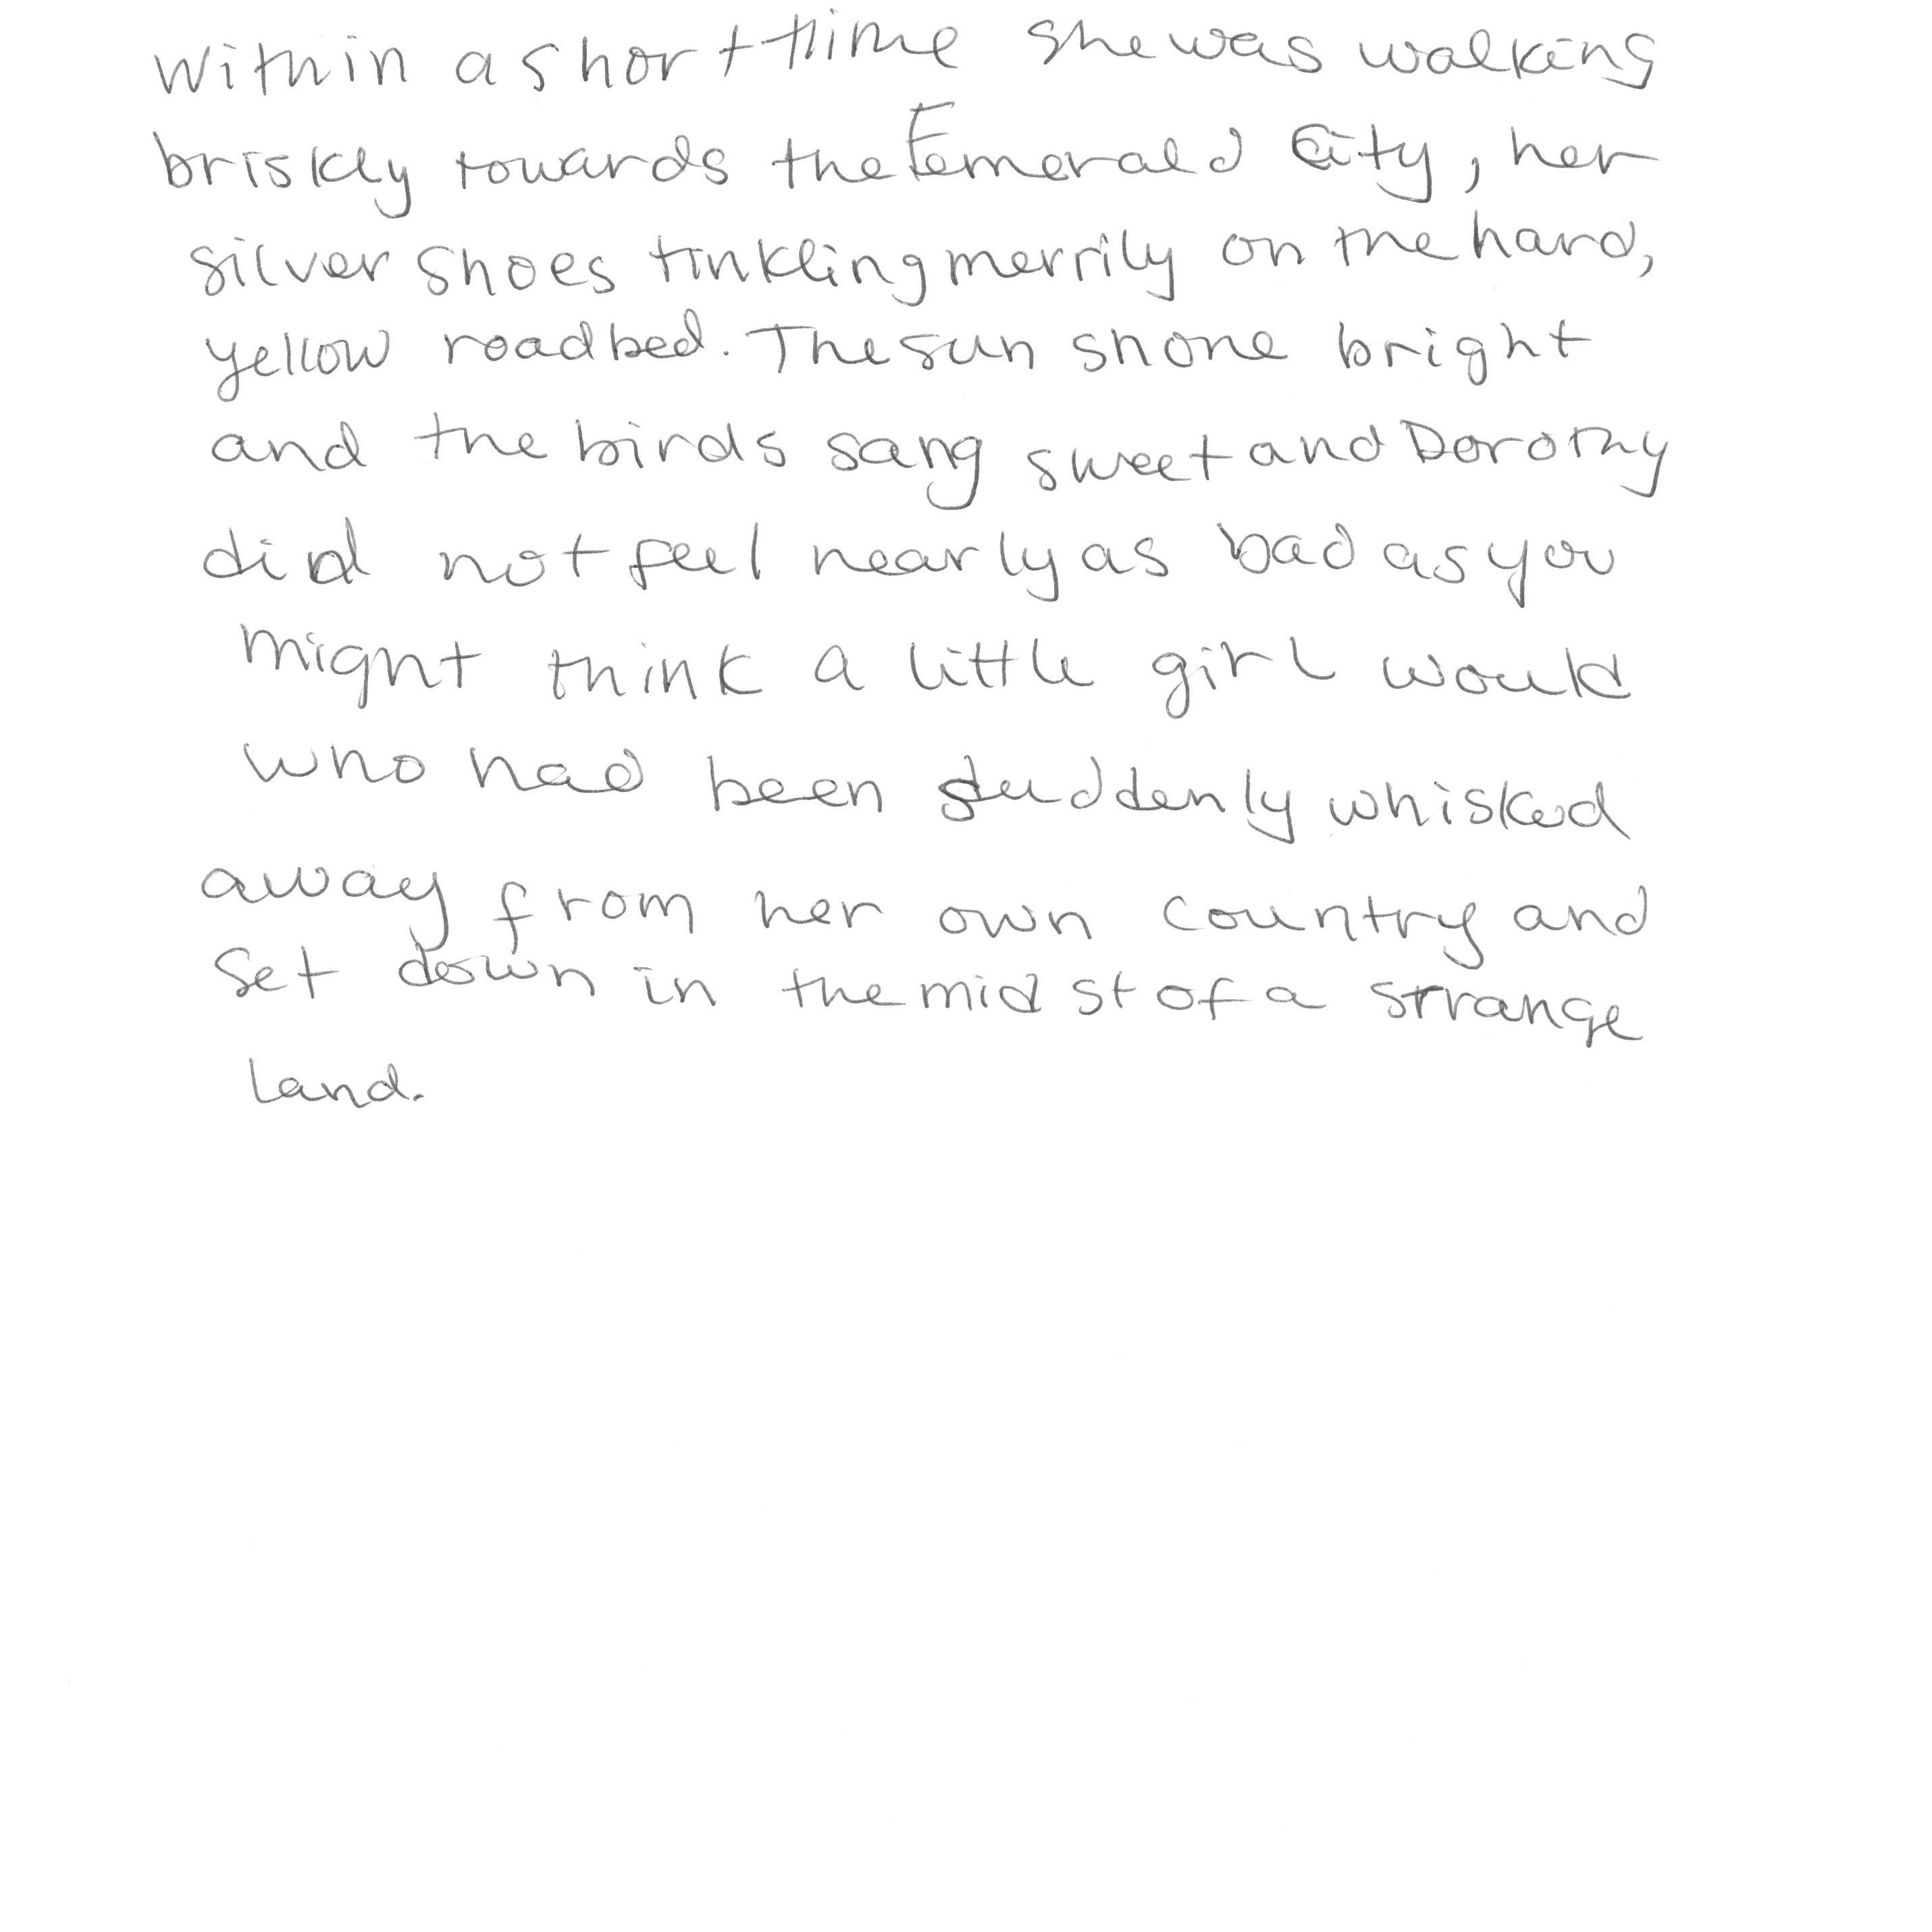

In [13]:
from IPython.display import Image, display
display(Image(random.choice(train_img_paths)))

In [ ]:
def square_and_downscale(input_root, output_root, target_size=(384, 384)):
    for class_name in os.listdir(input_root):
        class_path = os.path.join(input_root, class_name)
        if not os.path.isdir(class_path): continue

        output_class_path = os.path.join(output_root, class_name)
        os.makedirs(output_class_path, exist_ok=True)

        print(f"Processing {class_name}...")

        for img_name in tqdm(os.listdir(class_path)):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                full_path = os.path.join(class_path, img_name)

                with Image.open(full_path) as img:
                    img = img.convert("RGB")
                    w, h = img.size

                    # 1. Create the square canvas based on the larger dimension
                    max_dim = max(w, h)
                    # Use a white background
                    squared_img = Image.new("RGB", (max_dim, max_dim), (255, 255, 255))

                    # 2. Paste original image
                    # This puts it at the top-left, padding the right or bottom
                    squared_img.paste(img, (0, 0))

                    # 3. High-quality resize to your model's input size
                    # LANCZOS is best for shrinking high-res images without aliasing
                    final_img = squared_img.resize(target_size, Image.Resampling.LANCZOS)

                    # 4. Save as a compressed JPEG to save space
                    final_img.save(os.path.join(output_class_path, img_name), quality=95)

# Execute
#square_and_downscale(data_dir, new_data_dir2)

## train/test/val

In [ ]:
help(reload_data2.stratify_split_alt)

Help on function stratify_split_alt in module reload_data2:

stratify_split_alt(source_dir, w_ids=90, split=(15, 6, 6))
    Re-organizes images in writer folders into train/val/test folders with writer sub-directories.



In [14]:
train_ds,val_ds,test_ds=reload_data2.train_val_test_split(new_data_dir,IMAGE_SIZE,BATCH_SIZE)

Found 7125 files belonging to 475 classes.
Found 2850 files belonging to 475 classes.
Found 2850 files belonging to 475 classes.


In [15]:
! zip -r AllClass2_test.zip /content/New_Data/test

  adding: content/New_Data/test/ (stored 0%)
  adding: content/New_Data/test/w0348/ (stored 0%)
  adding: content/New_Data/test/w0348/w0348_s01_pPHR_r02.png (deflated 13%)
  adding: content/New_Data/test/w0348/w0348_s02_pLND_r02.png (deflated 5%)
  adding: content/New_Data/test/w0348/w0348_s01_pLND_r02.png (deflated 5%)
  adding: content/New_Data/test/w0348/w0348_s03_pLND_r03.png (deflated 7%)
  adding: content/New_Data/test/w0348/w0348_s01_pLND_r03.png (deflated 6%)
  adding: content/New_Data/test/w0348/w0348_s02_pPHR_r01.png (deflated 16%)
  adding: content/New_Data/test/w0647/ (stored 0%)
  adding: content/New_Data/test/w0647/w0647_s01_pWOZ_r03.png (deflated 4%)
  adding: content/New_Data/test/w0647/w0647_s01_pPHR_r02.png (deflated 8%)
  adding: content/New_Data/test/w0647/w0647_s02_pWOZ_r03.png (deflated 5%)
  adding: content/New_Data/test/w0647/w0647_s02_pWOZ_r01.png (deflated 5%)
  adding: content/New_Data/test/w0647/w0647_s03_pPHR_r01.png (deflated 9%)
  adding: content/New_Data

In [16]:
for x in reload_data2.w_ids475:
    shutil.rmtree(f"{new_data_dir}/{x}")

In [17]:
#save whole dataset
! zip -rq AllClass2_data.zip /content/New_Data

# Model building

In [18]:
def make_transfer_model(input_shape, num_classes, name):
    backbone = base_model

    backbone.trainable = False

    inputs = layers.Input(input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation=None)(x)

    return keras.Model(inputs, outputs, name=name)

base_model = keras.applications.MobileNetV2(
                        include_top = False,
                        classifier_activation="softmax",
                        weights = "imagenet",
                        input_shape=(IMAGE_SIZE + (3,))
                        )

model = make_transfer_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES,
                            name="mobilenet_allclass2")
model.summary()

/tmp/ipykernel_1040/3537128474.py:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenet_allclass2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 475)            │       608,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,866,459 (10.93 MB)

 Trainable params: 608,475 (2.32 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# epochs

In [19]:
%%time

epochs = 80

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), ###make sure is true
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("/content/drive/MyDrive/CSAFE_zips/MobileNetV2_allclass2.keras")

Epoch 1/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - acc: 0.0048 - loss: 6.6490 - top3_acc: 0.0118 - val_acc: 0.0340 - val_loss: 5.6287 - val_top3_acc: 0.0793
Epoch 2/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 100s 891ms/step - acc: 0.0444 - loss: 5.5404 - top3_acc: 0.0925 - val_acc: 0.1021 - val_loss: 5.1072 - val_top3_acc: 0.2014
Epoch 3/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 100s 890ms/step - acc: 0.0928 - loss: 5.0247 - top3_acc: 0.1845 - val_acc: 0.1582 - val_loss: 4.7116 - val_top3_acc: 0.2765
Epoch 4/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 100s 890ms/step - acc: 0.1451 - loss: 4.6212 - top3_acc: 0.2573 - val_acc: 0.2046 - val_loss: 4.4077 - val_top3_acc: 0.3375
Epoch 5/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 100s 893ms/step - acc: 0.2134 - loss: 4.2328 - top3_acc: 0.3504 - val_acc: 0.2635 - val_loss: 4.1404 - val_top3_acc: 0.3958
Epoch 6/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 100s 892ms/step - acc: 0.2548 - loss: 3.9503 - top3_acc: 0.4002 - val_acc: 0.2870 - val_loss: 3.9191 - val_top3_acc: 0.4344
Epoch 7/80
112/112 

In [20]:
#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv(f"/content/drive/MyDrive/CSAFE_zips/AllClass2_lossacc.csv")

In [23]:
lossacc.to_csv(f"AllClass2_lossacc.csv")
model.save(f"MobileNetV2_allclass2.keras")

### Visualization

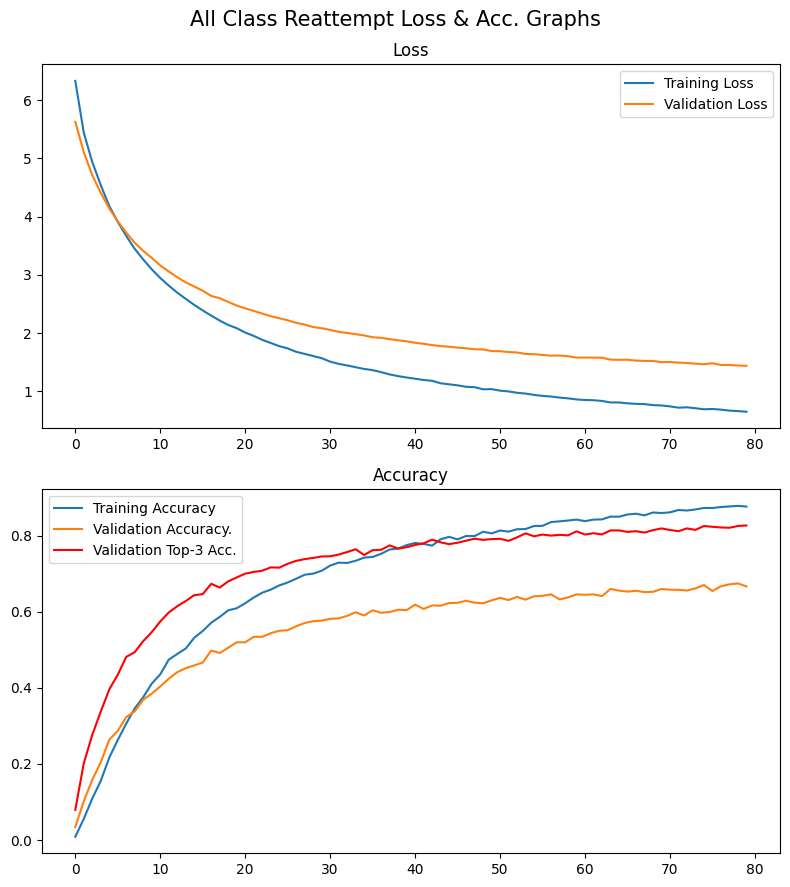

In [21]:
plt.figure(figsize=(8,9))
plt.suptitle("All Class Reattempt Loss & Acc. Graphs",size=15)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["val_top3_acc"])),history.history["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Test Set

In [22]:
results = model.evaluate(test_ds, return_dict=True)

print(results)

45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 632ms/step - acc: 0.6617 - loss: 1.4905 - top3_acc: 0.8090
{'acc': 0.672631561756134, 'loss': 1.4498701095581055, 'top3_acc': 0.8175438642501831}
